In [1]:
!pip install -q tensorflow matplotlib scikit-learn


In [2]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score


In [3]:
(train_images, _), (test_images, _) = tf.keras.datasets.mnist.load_data()

train_images = train_images.reshape(-1, 28, 28, 1).astype("float32")
train_images = (train_images - 127.5) / 127.5  # Normalize to [-1,1]

BUFFER_SIZE = 60000
BATCH_SIZE = 128

train_dataset = tf.data.Dataset.from_tensor_slices(train_images)\
    .shuffle(BUFFER_SIZE).batch(BATCH_SIZE)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
def make_generator():
    model = tf.keras.Sequential([
        layers.Dense(7*7*256, use_bias=False, input_shape=(100,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7,7,256)),

        layers.Conv2DTranspose(128, (5,5), strides=(1,1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(1, (5,5), strides=(2,2),
                               padding='same', use_bias=False, activation='tanh')
    ])
    return model

generator = make_generator()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
def make_discriminator():
    model = tf.keras.Sequential([
        layers.Conv2D(64, (5,5), strides=(2,2), padding='same',
                      input_shape=[28,28,1]),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5,5), strides=(2,2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

discriminator = make_discriminator()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
cross_entropy = tf.keras.losses.BinaryCrossentropy()

generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)


In [7]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, 100])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        d_loss_real = cross_entropy(tf.ones_like(real_output), real_output)
        d_loss_fake = cross_entropy(tf.zeros_like(fake_output), fake_output)
        d_loss = d_loss_real + d_loss_fake

        g_loss = cross_entropy(tf.ones_like(fake_output), fake_output)

    gradients_of_generator = gen_tape.gradient(g_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(d_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return g_loss, d_loss


In [8]:
def compute_precision_recall():
    real_samples = test_images[:500]
    real_samples = (real_samples - 127.5) / 127.5
    real_samples = real_samples.reshape(-1,28,28,1)

    noise = tf.random.normal([500, 100])
    fake_samples = generator(noise, training=False)

    real_preds = discriminator(real_samples, training=False)
    fake_preds = discriminator(fake_samples, training=False)

    y_true = np.concatenate([np.ones(500), np.zeros(500)])
    y_pred = np.concatenate([
        real_preds.numpy().flatten(),
        fake_preds.numpy().flatten()
    ]) > 0.5

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)

    return precision, recall


Epoch 1 | G Loss: 0.9884 | D Loss: 1.3525 | Precision: 0.6343 | Recall: 0.9020


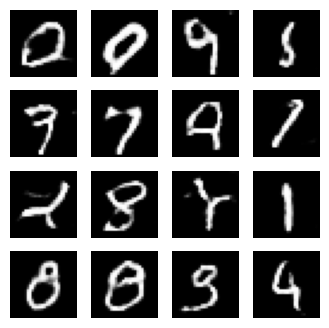

Epoch 2 | G Loss: 0.7241 | D Loss: 1.3070 | Precision: 0.7666 | Recall: 0.4400
Epoch 3 | G Loss: 0.8023 | D Loss: 1.1806 | Precision: 0.7932 | Recall: 0.7900
Epoch 4 | G Loss: 0.7590 | D Loss: 1.4034 | Precision: 0.5892 | Recall: 0.9580
Epoch 5 | G Loss: 0.8400 | D Loss: 1.2800 | Precision: 0.6401 | Recall: 0.8360
Epoch 6 | G Loss: 0.8614 | D Loss: 1.3252 | Precision: 0.6278 | Recall: 0.8500


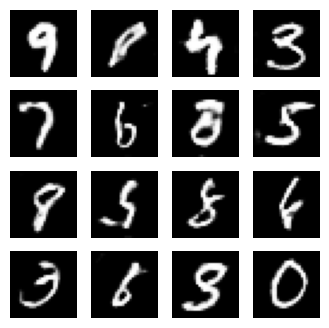

Epoch 7 | G Loss: 0.6814 | D Loss: 1.3485 | Precision: 0.6501 | Recall: 0.8620
Epoch 8 | G Loss: 0.8985 | D Loss: 1.2695 | Precision: 0.7384 | Recall: 0.8240
Epoch 9 | G Loss: 0.9180 | D Loss: 1.4251 | Precision: 0.8549 | Recall: 0.3300
Epoch 10 | G Loss: 0.7787 | D Loss: 1.3161 | Precision: 0.6912 | Recall: 0.7700
Epoch 11 | G Loss: 0.8272 | D Loss: 1.2877 | Precision: 0.7392 | Recall: 0.7880


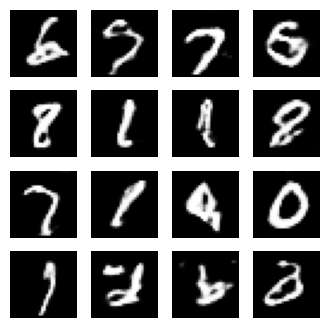

Epoch 12 | G Loss: 0.8285 | D Loss: 1.3147 | Precision: 0.6537 | Recall: 0.8380
Epoch 13 | G Loss: 0.8186 | D Loss: 1.2886 | Precision: 0.7534 | Recall: 0.7760
Epoch 14 | G Loss: 0.8893 | D Loss: 1.2829 | Precision: 0.6267 | Recall: 0.9100
Epoch 15 | G Loss: 0.8212 | D Loss: 1.2654 | Precision: 0.8116 | Recall: 0.5600
Epoch 16 | G Loss: 0.6786 | D Loss: 1.3704 | Precision: 0.8283 | Recall: 0.3860


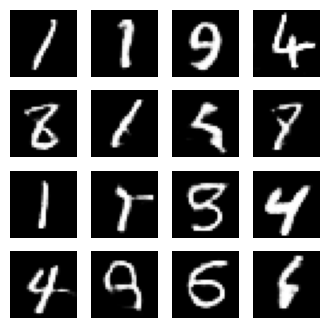

Epoch 17 | G Loss: 0.8060 | D Loss: 1.3005 | Precision: 0.7488 | Recall: 0.6380
Epoch 18 | G Loss: 0.7623 | D Loss: 1.3419 | Precision: 0.7318 | Recall: 0.8020
Epoch 19 | G Loss: 0.8773 | D Loss: 1.2695 | Precision: 0.6928 | Recall: 0.8300
Epoch 20 | G Loss: 0.8260 | D Loss: 1.3150 | Precision: 0.7488 | Recall: 0.6020
Epoch 21 | G Loss: 0.7888 | D Loss: 1.2754 | Precision: 0.7896 | Recall: 0.7280


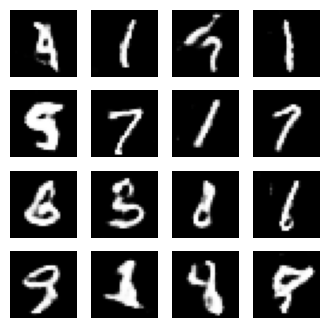

Epoch 22 | G Loss: 0.8256 | D Loss: 1.2970 | Precision: 0.7317 | Recall: 0.7580
Epoch 23 | G Loss: 0.7483 | D Loss: 1.3596 | Precision: 0.7759 | Recall: 0.6580
Epoch 24 | G Loss: 0.7934 | D Loss: 1.3210 | Precision: 0.8490 | Recall: 0.5960
Epoch 25 | G Loss: 0.8363 | D Loss: 1.3039 | Precision: 0.7143 | Recall: 0.7000
Epoch 26 | G Loss: 0.6588 | D Loss: 1.3999 | Precision: 0.7547 | Recall: 0.8060


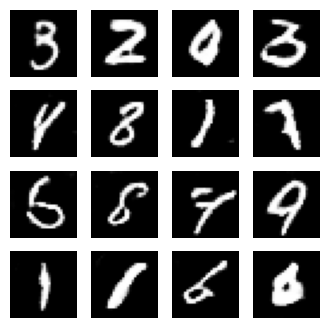

Epoch 27 | G Loss: 0.8539 | D Loss: 1.3272 | Precision: 0.6549 | Recall: 0.7820
Epoch 28 | G Loss: 0.8305 | D Loss: 1.3317 | Precision: 0.5900 | Recall: 0.9240
Epoch 29 | G Loss: 0.7468 | D Loss: 1.3405 | Precision: 0.8547 | Recall: 0.5880
Epoch 30 | G Loss: 0.8959 | D Loss: 1.3636 | Precision: 0.6789 | Recall: 0.8120
Epoch 31 | G Loss: 0.8297 | D Loss: 1.2353 | Precision: 0.7100 | Recall: 0.8520


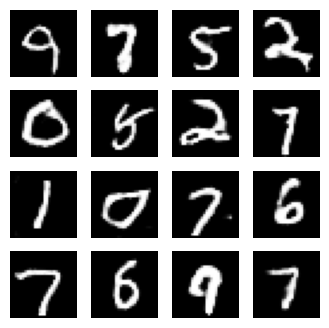

Epoch 32 | G Loss: 0.8349 | D Loss: 1.3249 | Precision: 0.6954 | Recall: 0.5800
Epoch 33 | G Loss: 0.7702 | D Loss: 1.2839 | Precision: 0.7769 | Recall: 0.5920
Epoch 34 | G Loss: 0.7932 | D Loss: 1.3613 | Precision: 0.8683 | Recall: 0.5800
Epoch 35 | G Loss: 0.8392 | D Loss: 1.3226 | Precision: 0.7035 | Recall: 0.8540


In [11]:
EPOCHS = 35

g_losses = []
d_losses = []
precisions = []
recalls = []

for epoch in range(EPOCHS):
    for image_batch in train_dataset:
        g_loss, d_loss = train_step(image_batch)

    precision, recall = compute_precision_recall()

    g_losses.append(g_loss.numpy())
    d_losses.append(d_loss.numpy())
    precisions.append(precision)
    recalls.append(recall)

    print(f"Epoch {epoch+1} | G Loss: {g_loss:.4f} | D Loss: {d_loss:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")

    if epoch % 5 == 0:
        noise = tf.random.normal([16,100])
        predictions = generator(noise, training=False)

        plt.figure(figsize=(4,4))
        for i in range(16):
            plt.subplot(4,4,i+1)
            plt.imshow(predictions[i,:,:,0]*127.5+127.5, cmap='gray')
            plt.axis('off')
        plt.savefig(f"epoch_{epoch}.png")
        plt.show()


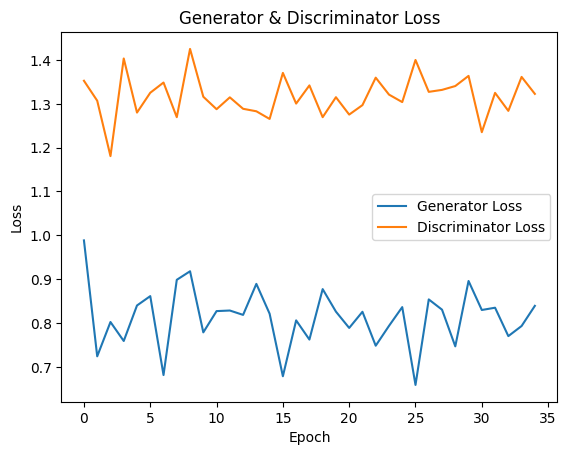

In [12]:
plt.figure()
plt.plot(g_losses)
plt.plot(d_losses)
plt.title("Generator & Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Generator Loss", "Discriminator Loss"])
plt.show()


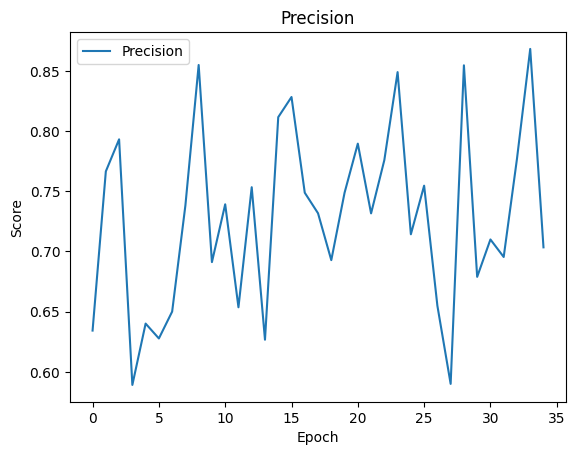

In [13]:
plt.figure()
plt.plot(precisions)
plt.title("Precision")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend(["Precision"])
plt.show()


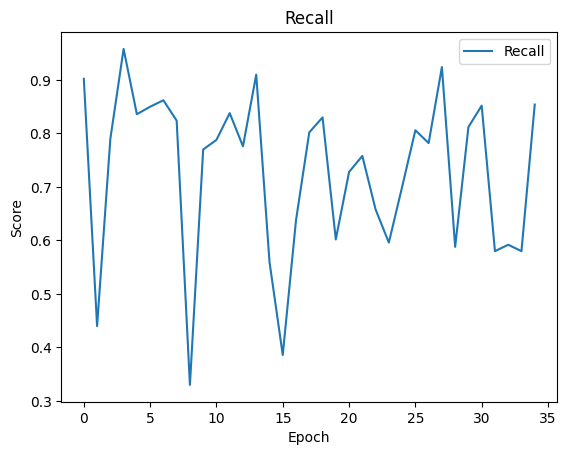

In [14]:
plt.figure()
plt.plot(recalls)
plt.title("Recall")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend(["Recall"])
plt.show()


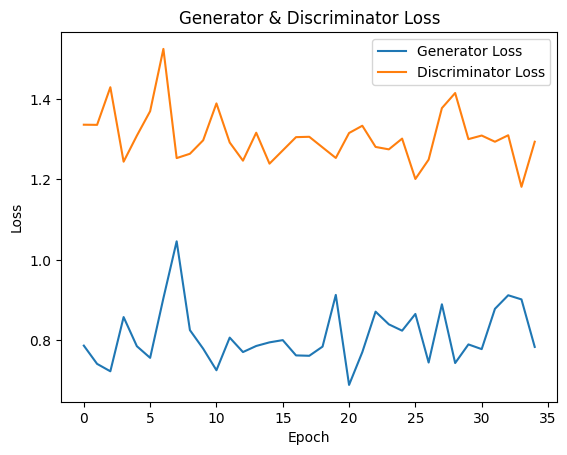

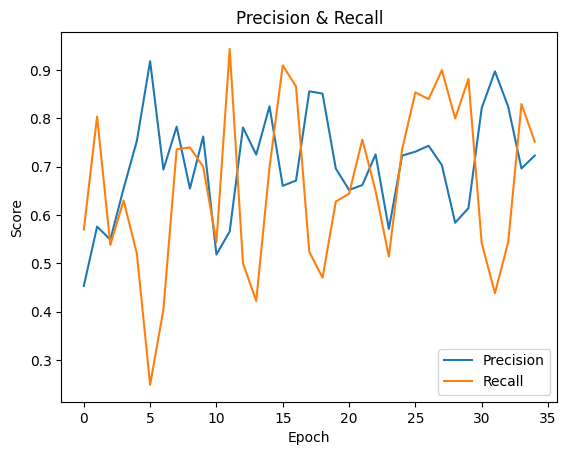

In [10]:
plt.figure()
plt.plot(g_losses)
plt.plot(d_losses)
plt.title("Generator & Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Generator Loss", "Discriminator Loss"])
plt.show()

plt.figure()
plt.plot(precisions)
plt.plot(recalls)
plt.title("Precision & Recall")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend(["Precision", "Recall"])
plt.show()
